# Interpretabilidad con LIME

Total mal clasificadas: 53609

══════════════════════════════════════════════
  LIME — Falso Positivo (real=0, pred=1)
══════════════════════════════════════════════
  Probabilidades : [0.4955473 0.5044527]


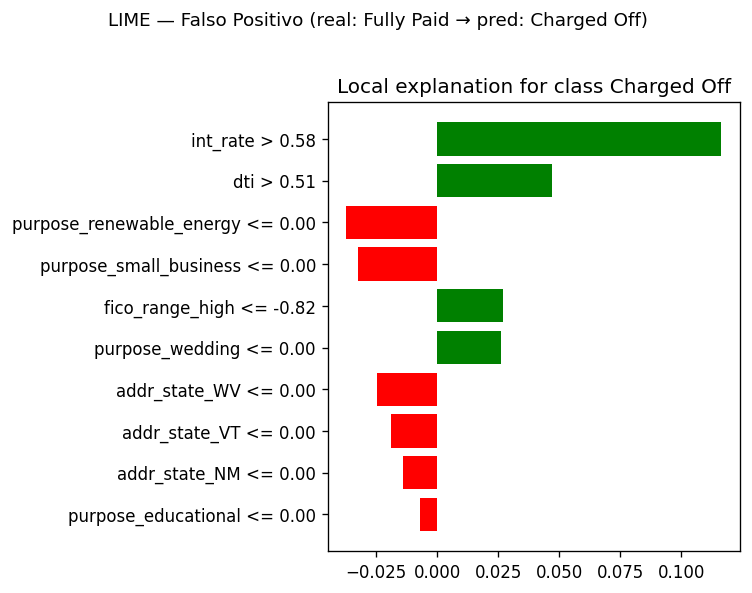


══════════════════════════════════════════════
  LIME — Falso Negativo (real=1, pred=0)
══════════════════════════════════════════════
  Probabilidades : [0.81283636 0.18716364]


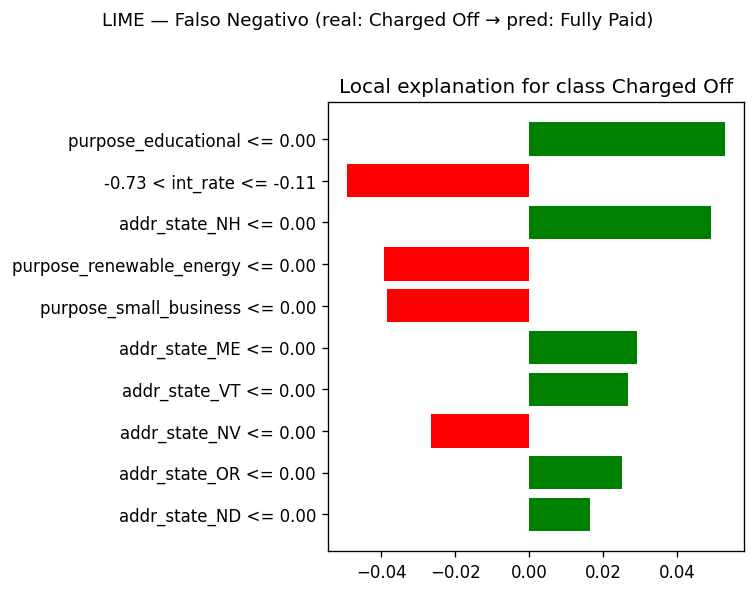

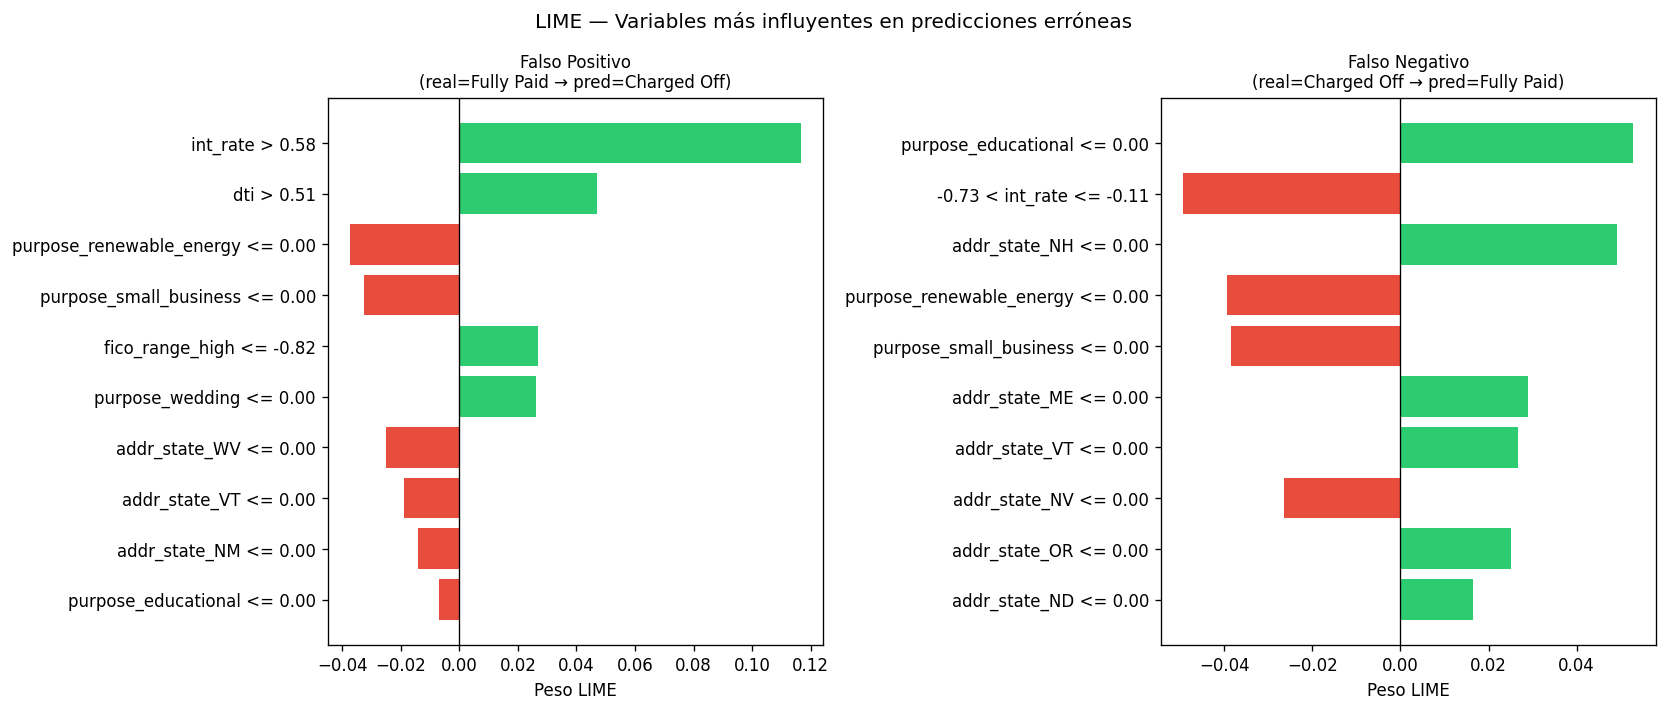

In [ ]:
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── 1. Identificar instancias mal clasificadas ───────────────────────────────
y_pred_all = grid.predict(X_test_proc)
wrong_idx  = np.where(y_pred_all != y_test.values)[0]
print(f"Total mal clasificadas: {len(wrong_idx)}")

# Seleccionar 2 instancias: un FP y un FN
fp_idx = wrong_idx[y_test.values[wrong_idx] == 0][0]   # Fully Paid → pred Charged Off
fn_idx = wrong_idx[y_test.values[wrong_idx] == 1][0]   # Charged Off → pred Fully Paid

# ── 2. LimeTabularExplainer ──────────────────────────────────────────────────
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data   = X_train_proc,
    feature_names   = all_feature_names,
    class_names     = ["Fully Paid", "Charged Off"],
    mode            = "classification",
    discretize_continuous = True,
    random_state    = 42
)

# ── 3. Explicar FP (Falso Positivo) ─────────────────────────────────────────
exp_fp = explainer.explain_instance(
    data_row       = X_test_proc[fp_idx],
    predict_fn     = grid.predict_proba,
    num_features   = 10
)

print("\n══════════════════════════════════════════════")
print("  LIME — Falso Positivo (real=0, pred=1)")
print("══════════════════════════════════════════════")
print(f"  Probabilidades : {grid.predict_proba(X_test_proc[[fp_idx]])[0]}")
fig_fp = exp_fp.as_pyplot_figure()
fig_fp.suptitle("LIME — Falso Positivo (real: Fully Paid → pred: Charged Off)",
                fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# ── 4. Explicar FN (Falso Negativo) ─────────────────────────────────────────
exp_fn = explainer.explain_instance(
    data_row       = X_test_proc[fn_idx],
    predict_fn     = grid.predict_proba,
    num_features   = 10
)

print("\n══════════════════════════════════════════════")
print("  LIME — Falso Negativo (real=1, pred=0)")
print("══════════════════════════════════════════════")
print(f"  Probabilidades : {grid.predict_proba(X_test_proc[[fn_idx]])[0]}")
fig_fn = exp_fn.as_pyplot_figure()
fig_fn.suptitle("LIME — Falso Negativo (real: Charged Off → pred: Fully Paid)",
                fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# ── 5. Top features side-by-side ────────────────────────────────────────────
def plot_lime_bar(exp, title, ax):
    features_vals = exp.as_list()
    features_vals.sort(key=lambda x: abs(x[1]))
    labels  = [f[0] for f in features_vals]
    weights = [f[1] for f in features_vals]
    colors  = ["#e74c3c" if w < 0 else "#2ecc71" for w in weights]
    ax.barh(labels, weights, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Peso LIME")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_lime_bar(exp_fp, "Falso Positivo\n(real=Fully Paid → pred=Charged Off)", axes[0])
plot_lime_bar(exp_fn, "Falso Negativo\n(real=Charged Off → pred=Fully Paid)", axes[1])
plt.suptitle("LIME — Variables más influyentes en predicciones erróneas", fontsize=12)
plt.tight_layout()
plt.show()